<a href="https://colab.research.google.com/github/vivekkuamar-dudhat/Artificial_intelligence/blob/main/Artificial_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalise pixel values (0-255 -> 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Print dataset shapes
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


In [ ]:
def build_model(activation_function):
    """
    Builds a neural network model with:
    - 1 Input Layer
    - 6 Hidden Layers
    - 1 Output Layer

    Parameters:
        activation_function: 'sigmoid' or 'tanh'

    Returns:
        Compiled Keras model
    """

    model = Sequential()

    # Input Layer (Flatten converts 28x28 image to 1D vector)
    model.add(Flatten(input_shape=(28, 28)))

    # Hidden Layers (6 Layers)

    model.add(Dense(256, activation=activation_function))
    model.add(Dense(128, activation=activation_function))
    model.add(Dense(128, activation=activation_function))
    model.add(Dense(64, activation=activation_function))
    model.add(Dense(64, activation=activation_function))
    model.add(Dense(32, activation=activation_function))

        # Output Layer (10 Classes)

    model.add(Dense(10, activation='softmax'))

    # Compile Model

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def train_model(model, model_name):

    print(f"\nTraining {model_name} Model...\n")

    history = model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    return history

In [ ]:
def evaluate_model(model, model_name):

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    print(f"\n{model_name} Model Performance:")
    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)

    return test_loss, test_accuracy

In [ ]:
def plot_results(history, model_name):

    # Accuracy Graph
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f"{model_name} Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Training", "Validation"])
    plt.show()

    # Loss Graph
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f"{model_name} Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Training", "Validation"])
    plt.show()


SIGMOID MODEL SUMMARY


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,194 (1.01 MB)

 Trainable params: 265,194 (1.01 MB)

 Non-trainable params: 0 (0.00 B)


Training Sigmoid Model...

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1899 - loss: 2.1628 - val_accuracy: 0.6621 - val_loss: 1.1168
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6982 - loss: 0.9802 - val_accuracy: 0.8187 - val_loss: 0.6445
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8338 - loss: 0.5782 - val_accuracy: 0.8561 - val_loss: 0.4573
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8994 - loss: 0.3992 - val_accuracy: 0.9388 - val_loss: 0.2824
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9437 - loss: 0.2543 - val_accuracy: 0.9491 - val_loss: 0.2241
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9560 - loss: 0.1955 - val_accuracy: 0.9525 - val_loss: 0.2012
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9627 - loss: 0.1653 - val_accuracy: 0.9585 - val_loss: 0.1801
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9649 - 

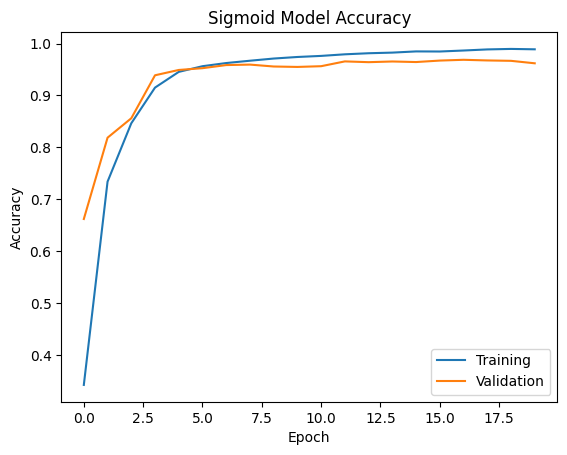

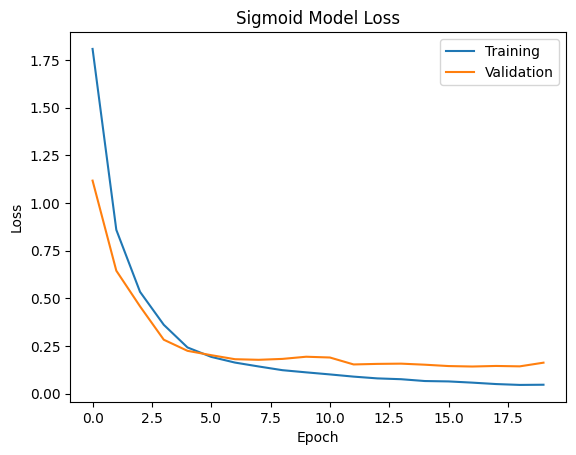

In [ ]:
# Build Sigmoid Model
sigmoid_model = build_model("sigmoid")

# Display model structure
print("\nSIGMOID MODEL SUMMARY")
sigmoid_model.summary()

# Train Sigmoid Model
sigmoid_history = train_model(sigmoid_model, "Sigmoid")

# Evaluate Sigmoid Model
sigmoid_loss, sigmoid_accuracy = evaluate_model(sigmoid_model, "Sigmoid")

# Plot Sigmoid Results
plot_results(sigmoid_history, "Sigmoid")


TANH MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,194 (1.01 MB)

 Trainable params: 265,194 (1.01 MB)

 Non-trainable params: 0 (0.00 B)


Training Tanh Model...

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8312 - loss: 0.6220 - val_accuracy: 0.9503 - val_loss: 0.1717
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9521 - loss: 0.1650 - val_accuracy: 0.9628 - val_loss: 0.1257
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9705 - loss: 0.1018 - val_accuracy: 0.9661 - val_loss: 0.1130
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9769 - loss: 0.0783 - val_accuracy: 0.9674 - val_loss: 0.1098
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9815 - loss: 0.0608 - val_accuracy: 0.9710 - val_loss: 0.0985
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9847 - loss: 0.0500 - val_accuracy: 0.9732 - val_loss: 0.0943
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9868 - loss: 0.0423 - val_accuracy: 0.9697 - val_loss: 0.1038
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9894 - los

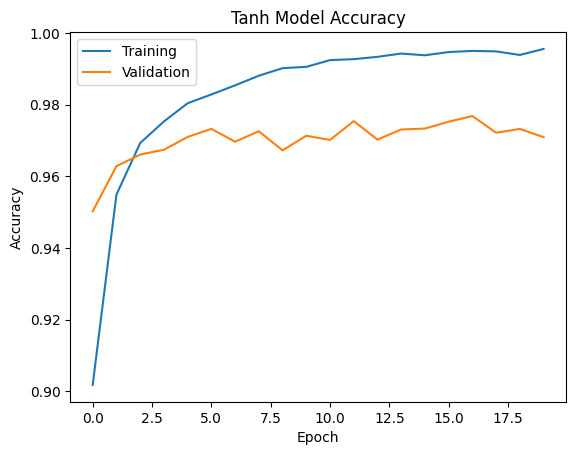

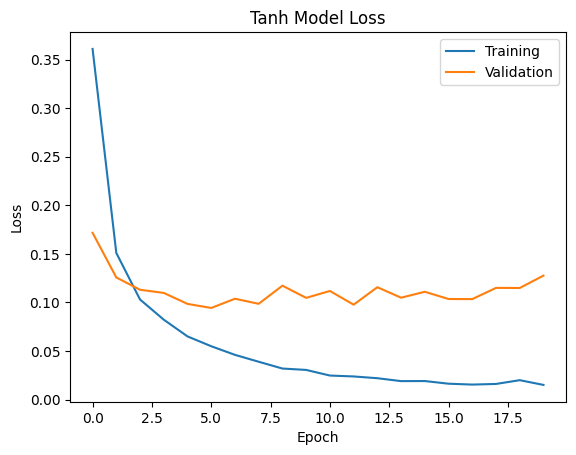

In [ ]:
# Build Tanh Model
tanh_model = build_model("tanh")

# Display model structure
print("\nTANH MODEL SUMMARY")
tanh_model.summary()

# Train Tanh Model
tanh_history = train_model(tanh_model, "Tanh")

# Evaluate Tanh Model
tanh_loss, tanh_accuracy = evaluate_model(tanh_model, "Tanh")

# Plot Tanh Results
plot_results(tanh_history, "Tanh")

In [ ]:

print("\n================ FINAL COMPARISON ================\n")

print("Sigmoid Test Accuracy:", sigmoid_accuracy)
print("Tanh Test Accuracy:", tanh_accuracy)

if tanh_accuracy > sigmoid_accuracy:
    print("Conclusion: Tanh performed better than Sigmoid.")
else:
    print("Conclusion: Sigmoid performed better than Tanh.")


print("\n==================================================\n")



================ FINAL COMPARISON ================

Sigmoid Test Accuracy: 0.9606999754905701
Tanh Test Accuracy: 0.9735000133514404
Conclusion: Tanh performed better than Sigmoid.




In [ ]:
sigmoid_model.save("mnist_sigmoid_model.h5")
tanh_model.save("mnist_tanh_model.h5")

print("Models saved successfully.")


Models saved successfully.
